<img src="./image/3.png" alt="bank" style="width: 100%; height: 100%; object-fit: cover; border-radius: 20px;">

<div style="padding: 10px; background-image: linear-gradient(to right, #FFFBF5, #ECE3CE); border: 2px solid #000; border-radius: 10px; font-family: avenir;">

# Определение перспективного тарифа для телеком-компании "Мегалайн"

## 🎯 Цель проекта

Провести предварительный анализ поведения клиентов, пользующихся тарифными планами "Смарт" и "Ультра", чтобы определить, какой тариф прибыльнее с точки зрения компании.

## 📊 Входные данные

Данные 500 пользователей «Мегалайна» за 2018 год:
- Файл `users`
- Файл `tariffs`
- Файл `calls`
- Файл `internet`
- Файл `messages`

## 📝 Описание тарифов

### Тариф «Смарт»
- Ежемесячная плата: 550 рублей
- Включено: 500 минут, 50 сообщений, 15 Гб
- Стоимость сверх пакета: 3 руб/мин, 3 руб/сообщение, 200 руб/Гб

### Тариф «Ультра»
- Ежемесячная плата: 1950 рублей
- Включено: 3000 минут, 1000 сообщений, 30 Гб
- Стоимость сверх пакета: 1 руб/мин, 1 руб/сообщение, 150 руб/Гб

## 🔍 Ход исследования

### [1️⃣ Обзор данных](#overview)
- Анализ структуры и содержания датасетов
- Выявление потенциальных проблем и ошибок

### [2️⃣ Предобработка данных](#preprocessing)
- Очистка и подготовка данных для анализа
- Объединение данных из разных файлов

### [3️⃣ Расчеты](#calculations)
- Расчет месячной выручки по каждому пользователю
- Учет особенностей тарификации (округление минут и трафика)

### [4️⃣ Анализ данных](#eda)
- Анализ поведения пользователей разных тарифов
- Сравнение выручки от разных тарифов
- Анализ географического распределения пользователей

### [5️⃣ Проверка гипотез](#hypotheses)
 - [1. Средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются](#hyp_1)
 - [2. Средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов](#hyp_2)

## 🚀 Ожидаемые результаты

По итогам исследования мы планируем:
- Определить, какой тариф приносит больше прибыли компании
- Выявить различия в поведении пользователей разных тарифов
- Предоставить рекомендации для корректировки рекламного бюджета

<a id='menu'></a>

In [1]:
# Ignore Warnings
import warnings

# Data Manipulation
import pandas as pd
import numpy as np



# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns



# Stats
from scipy import stats as st
import scipy.stats as stats
from scipy.stats import shapiro
from scipy.stats import norm


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


%config InlineBackend.figure_format = 'svg'
warnings.filterwarnings('ignore')  # Disabling warning outputs


## <a id='first'></a> 1️⃣ Обзор данных


[**Главное меню**](#menu)

In [2]:
# Прописываем путь к файлу `users.csv`
USER_DATAPATH = './data/users.csv'

# Прописываем путь к файлу `tariffs.csv`
TARIFFS_DATAPATH = './data/tariffs.csv'

# Прописываем путь к файлу `messages.csv`
MESSAGES_DATAPATH = './data/messages.csv'

# Прописываем путь к файлу `internet.csv`
INTERNET_DATAPATH = './data/internet.csv'

# Прописываем путь к файлу `calls.csv`
CALLS_DATAPATH = './data/calls.csv'

# Read the training data into a pandas DataFrame
user_df = pd.read_csv(USER_DATAPATH)
tariffs_df = pd.read_csv(TARIFFS_DATAPATH)
messages_df = pd.read_csv(MESSAGES_DATAPATH)
internet_df = pd.read_csv(INTERNET_DATAPATH)
calls_df = pd.read_csv(CALLS_DATAPATH)

In [3]:
# Отображаем первые 5 наблюдений
user_df.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [4]:
# Отображаем первые 5 наблюдений
tariffs_df.head()

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


In [5]:
# Отображаем первые 5 наблюдений
messages_df.head()

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


In [6]:
# Отображаем первые 5 наблюдений
internet_df.head()

,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000


In [7]:
# Отображаем первые 5 наблюдений
calls_df.head()

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


### Документация к данным:

### `user_df`

- `user_id` - уникальный идентификатор пользователя
- `age` - возраст пользователя
- `churn_date` - дата ухода пользователя (отказа от услуг)
- `city` - город проживания пользователя
- `first_name` - имя пользователя
- `last_name` - фамилия пользователя
- `reg_date` - дата регистрации пользователя
- `tariff` - название тарифного плана пользователя

### `tariffs_df`

- `messages_included` - количество включенных в тарифный пакет СМС
- `mb_per_month_included` - количество включенных в тарифный пакет Гб интернет-трафика
- `minutes_included` - количество включенных в тарифный пакет минут
- `rub_monthly_fee` - абоненская плата
- `rub_per_gb` - стоимость 1 Гб интернет-трафика сверх тарифного пакета
- `rub_per_message` - стоимость 1 СМС сверх тарифного пакета
- `rub_per_minute` - стоимость 1 минуты сверх тарифного пакета
- `tariff_name` - наименование тарифа

### `messages_df`

- `id` - уникальный идентификатор сообщения
- `message_date` - дата и время отправки сообщения
- `user_id` - уникальный идентификатор пользователя, отправившего сообщение

### `internet_df`

- `id` - уникальный идентификатор сессии
- `mb_used` - объем использованного интернет-трафика в мегабайтах
- `session_date` - дата и время сессии
- `user_id` - уникальный идентификатор пользователя, совершившего сессию

### `calls_df`

- `id` - уникальный идентификатор звонка
- `call_date` - дата и время звонка
- `duration` - продолжительность звонка
- `user_id` - уникальный идентификатор пользователя, совершившего звонок

### Более детально изучим каждый датасет на предмет наличия аномалий и пропусков

In [8]:
def info(df):
    result = []
    for column in df.columns:
        dtype = df[column].dtype
        non_null_count = df[column].count()
        null_count = df[column].isnull().sum()
        unique_count = df[column].nunique()
        
        if np.issubdtype(dtype, np.number):
            min_value = df[column].min()
            max_value = df[column].max()
            mean_value = df[column].mean()
            median_value = df[column].median()
            mode_value = ''
        elif np.issubdtype(dtype, object):
            min_value = max_value = mean_value = median_value = ""
            mode_value = df[column].mode()[0]

        result.append({
            "Column": column,
            "Dtype": str(dtype),
            "Non-Null Count": non_null_count,
            "Missing": null_count,
            "% Missing": round(df[column].isnull().sum() / len(df) * 100, 2),
            "Uniques": unique_count,
            "Minimum": min_value,
            "Maximum": max_value,
            "Mean": mean_value,
            "Median": median_value,
            "Top": mode_value
        })
    
    info_df = pd.DataFrame(result)

    # Добавляем информацию о дубликатах строк и общем использовании памяти
    total_duplicates = df.duplicated().sum()
    total_memory = df.memory_usage(deep=True).sum()
    
    # Выводим результат
    print(info_df.to_string(index=False))
    
    # Выводим информацию о дубликатах красным цветом
    red_text = "\033[91m"
    reset_color = "\033[0m"
    print(f"\n{red_text}Total duplicate rows: {total_duplicates}{reset_color}")
    print(f"Total memory usage: {total_memory} bytes")



In [9]:
# Выводим информацию о user_df
info(user_df)

    Column  Dtype  Non-Null Count  Missing  % Missing  Uniques Minimum Maximum    Mean  Median        Top
   user_id  int64             500        0        0.0      500    1000    1499  1249.5  1249.5           
       age  int64             500        0        0.0       58      18      75  46.588    46.0           
churn_date object              38      462       92.4       33                                 2018-10-03
      city object             500        0        0.0       76                                     Москва
first_name object             500        0        0.0      246                                      Радим
 last_name object             500        0        0.0      419                                  Андреенко
  reg_date object             500        0        0.0      270                                 2018-05-28
    tariff object             500        0        0.0        2                                      smart

Total duplicate rows: 0
Total memory usage: 2

##### Из анализа данных о составе датасета можно заключить, что пропуски в графе `churn_date` - это действующие пользовтели, поэтому этот признак остаавляем без изменений 

In [10]:
# Выводим информацию о tariffs_df
info(tariffs_df)

               Column  Dtype  Non-Null Count  Missing  % Missing  Uniques Minimum Maximum     Mean   Median   Top
    messages_included  int64               2        0        0.0        2      50    1000    525.0    525.0      
mb_per_month_included  int64               2        0        0.0        2   15360   30720  23040.0  23040.0      
     minutes_included  int64               2        0        0.0        2     500    3000   1750.0   1750.0      
      rub_monthly_fee  int64               2        0        0.0        2     550    1950   1250.0   1250.0      
           rub_per_gb  int64               2        0        0.0        2     150     200    175.0    175.0      
      rub_per_message  int64               2        0        0.0        2       1       3      2.0      2.0      
       rub_per_minute  int64               2        0        0.0        2       1       3      2.0      2.0      
          tariff_name object               2        0        0.0        2               

In [11]:
# Выводим информацию о messages_df
info(messages_df)

      Column  Dtype  Non-Null Count  Missing  % Missing  Uniques Minimum Maximum        Mean  Median        Top
          id object          123036        0        0.0   123036                                         1000_0
message_date object          123036        0        0.0      364                                     2018-12-31
     user_id  int64          123036        0        0.0      426    1000    1499  1256.98941  1271.0           

Total duplicate rows: 0
Total memory usage: 17186990 bytes


In [12]:
# Выводим информацию о internet_df
info(internet_df)

      Column   Dtype  Non-Null Count  Missing  % Missing  Uniques Minimum  Maximum         Mean   Median        Top
  Unnamed: 0   int64          149396        0        0.0   149396       0   149395      74697.5  74697.5           
          id  object          149396        0        0.0   149396                                            1000_0
     mb_used float64          149396        0        0.0    70003     0.0  1724.83   370.192426  348.015           
session_date  object          149396        0        0.0      365                                        2018-12-31
     user_id   int64          149396        0        0.0      497    1000     1499  1252.099842   1251.0           

Total duplicate rows: 0
Total memory usage: 23254256 bytes


In [13]:
internet_df = internet_df.drop(columns= 'Unnamed: 0')
internet_df

,id,mb_used,session_date,user_id
0,1000_0,112.95,2018-11-25,1000
1,1000_1,1052.81,2018-09-07,1000
2,1000_2,1197.26,2018-06-25,1000
3,1000_3,550.27,2018-08-22,1000
4,1000_4,302.56,2018-09-24,1000
...,...,...,...,...
149391,1499_152,318.90,2018-10-03,1499
149392,1499_153,490.13,2018-12-14,1499
149393,1499_154,0.00,2018-10-27,1499
149394,1499_155,1246.32,2018-11-26,1499


In [14]:
# Выводим информацию о calls_df
info(calls_df)

   Column   Dtype  Non-Null Count  Missing  % Missing  Uniques Minimum Maximum         Mean  Median        Top
       id  object          202607        0        0.0   202607                                          1000_0
call_date  object          202607        0        0.0      365                                      2018-12-31
 duration float64          202607        0        0.0     2871     0.0    38.0     6.755887     6.0           
  user_id   int64          202607        0        0.0      492    1000    1499  1253.940619  1260.0           

Total duplicate rows: 0
Total memory usage: 29937786 bytes


## <a id='preprocessing'></a> 2️⃣ Предобработка данных


[**Главное меню**](#menu)

Преобразование дат из строкового формата в datetime для всех релевантных столбцов в различных датафреймах

In [15]:
# Преобразование столбцов с датами в формат datetime
user_df['reg_date'] = pd.to_datetime(user_df['reg_date'], format='%Y-%m-%d')
user_df['churn_date'] = pd.to_datetime(user_df['churn_date'], format='%Y-%m-%d')
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'], format='%Y-%m-%d')
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'], format='%Y-%m-%d')
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'], format='%Y-%m-%d')

# Преобразование мегабайт в гигабайты и удаление старого столбца
tariffs_df['gb_per_month_included'] = tariffs_df['mb_per_month_included'] / 1024
tariffs_df = tariffs_df.drop(columns='mb_per_month_included')


 Проверим датасет на наличие неявных дуликатов

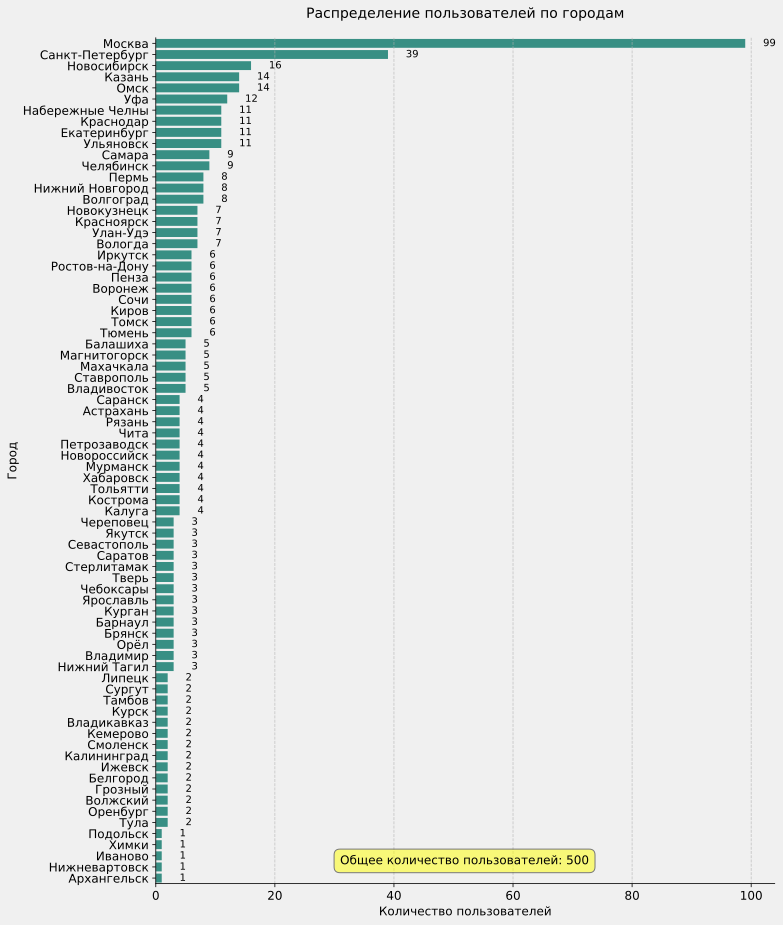

In [16]:
# Группировка и сортировка данных
user_df_grouped = user_df.groupby('city').size().sort_values(ascending=False).reset_index(name='total')

# Создание фигуры с большим разрешением
plt.figure(figsize=(11, 13), dpi=100)

# Создание столбчатой диаграммы
ax = sns.barplot(data=user_df_grouped, y='city', x='total', color='#2a9d8f')

# Настройка фона
ax.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')

# Настройка заголовка и меток осей
plt.title('Распределение пользователей по городам', fontsize=14, pad=20)
plt.xlabel('Количество пользователей', fontsize=12)
plt.ylabel('Город', fontsize=12)

# Добавление значений на концах столбцов
for i, v in enumerate(user_df_grouped['total']):
    ax.text(v + 3, i, str(v), va='center')

# Удаление верхней и правой границы графика
sns.despine()

# Добавление сетки для удобства чтения
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Настройка тиков оси X
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Добавление аннотации с общим количеством пользователей
total_users = user_df_grouped['total'].sum()
plt.annotate(f'Общее количество пользователей: {total_users}', 
             xy=(0.7, 0.02), xycoords='axes fraction', 
             fontsize=12, ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
             )

# Плотная компоновка и отображение графика
plt.tight_layout()
plt.show()

Создаем признаки с месяцами для расчетов и группировки по месяцам 

In [17]:
# Добавление столбцов с номером месяца для каждой даты
calls_df['call_month'] =calls_df['call_date'].dt.month
messages_df['message_month'] = messages_df['message_date'].dt.month
internet_df['session_month'] = internet_df['session_date'].dt.month
user_df['reg_date_month'] = user_df['reg_date'].dt.month
user_df['churn_date_month'] = user_df['churn_date'].dt.month

# Переименование столбца 'tariff_name' в 'tariff' в таблице тарифов
tariffs_df = tariffs_df.rename(columns={'tariff_name': 'tariff'})

## <a id='calculations'></a> 3️⃣ Расчеты

[**Главное меню**](#menu)

In [18]:
# Округление длительности звонков до ближайшего большего целого числа
calls_df['duration'] = np.ceil(calls_df['duration'])

In [19]:
# Создание сводной таблицы для звонков
calls_pivot = pd.pivot_table(
   data=calls_df,
   index='user_id',
   columns='call_month',
   values='duration',
   aggfunc='sum',
   fill_value=0
).reset_index().rename_axis(None, axis=1) 

# Вывод полученной сводной таблицы
calls_pivot

,user_id,1,2,3,4,5,6,7,8,9,10,11,12
0,1000,0,0,0,0,159,172,340,408,466,350,338,333
1,1001,0,0,0,0,0,0,0,0,0,0,430,414
2,1002,0,0,0,0,0,117,214,289,206,212,243,236
3,1003,0,0,0,0,0,0,0,380,961,855,824,802
4,1004,0,0,0,0,35,171,135,137,117,145,117,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,1495,0,0,0,0,0,0,0,92,813,1030,954,1031
488,1496,48,594,557,521,484,555,582,527,486,450,662,518
489,1497,0,0,0,0,0,0,0,0,0,490,371,545
490,1498,0,0,0,0,0,0,175,400,471,247,0,0


In [20]:
# Создание сводной таблицы для подсчета количества звонков
calls_count_pivot = calls_df.pivot_table(
   index = 'user_id', 
   columns = 'call_month', 
   values = 'duration',
   aggfunc = 'count',
   fill_value = 0).reset_index().rename_axis(None, axis=1)

# Вывод полученной сводной таблицы
calls_count_pivot

,user_id,1,2,3,4,5,6,7,8,9,10,11,12
0,1000,0,0,0,0,22,43,47,52,58,57,43,46
1,1001,0,0,0,0,0,0,0,0,0,0,59,63
2,1002,0,0,0,0,0,15,26,42,36,33,32,33
3,1003,0,0,0,0,0,0,0,55,134,108,115,108
4,1004,0,0,0,0,9,31,22,19,26,29,19,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,1495,0,0,0,0,0,0,0,17,112,152,129,155
488,1496,7,77,79,67,63,74,73,88,68,72,80,80
489,1497,0,0,0,0,0,0,0,0,0,66,64,71
490,1498,0,0,0,0,0,0,23,57,59,41,0,0


In [21]:
# Создание сводной таблицы для подсчета количества сообщений
messages_pivot = messages_df.pivot_table(
   index = 'user_id', 
   columns = 'message_month', 
   values = 'id',
   aggfunc = 'count',
   fill_value = 0).reset_index().rename_axis(None, axis=1)

# Вывод полученной сводной таблицы
messages_pivot

,user_id,1,2,3,4,5,6,7,8,9,10,11,12
0,1000,0,0,0,0,22,60,75,81,57,73,58,70
1,1002,0,0,0,0,0,4,11,13,4,10,16,12
2,1003,0,0,0,0,0,0,0,37,91,83,94,75
3,1004,0,0,0,0,95,134,181,151,146,165,158,162
4,1005,7,38,56,41,42,47,56,64,52,44,51,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,1495,0,0,0,0,0,0,0,13,82,82,79,84
422,1496,9,45,46,49,40,35,42,41,29,35,46,51
423,1497,0,0,0,0,0,0,0,0,0,20,14,17
424,1498,0,0,0,0,0,0,20,62,44,42,0,0


In [22]:

# Создание сводной таблицы для суммирования использованного интернет-трафика
internet_pivot = internet_df.pivot_table(
   index = 'user_id', 
   columns = 'session_month', 
   values = 'mb_used',
   aggfunc = 'sum',
   fill_value = 0).reset_index().rename_axis(None, axis=1)

# Преобразование мегабайт в гигабайты и округление вверх
for i in range(1, 13):
   internet_pivot[i] /= 1024
   internet_pivot[i] = np.ceil(internet_pivot[i])

# Вывод полученной сводной таблицы
internet_pivot

,user_id,1,2,3,4,5,6,7,8,9,10,11,12
0,1000,0.0,0.0,0.0,0.0,3.0,23.0,14.0,14.0,15.0,15.0,15.0,10.0
1,1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,14.0
2,1002,0.0,0.0,0.0,0.0,0.0,11.0,18.0,20.0,17.0,14.0,19.0,18.0
3,1003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,13.0,15.0,12.0,10.0
4,1004,0.0,0.0,0.0,0.0,14.0,18.0,22.0,28.0,15.0,19.0,16.0,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,1495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,33.0,29.0,39.0,23.0
493,1496,4.0,28.0,25.0,21.0,24.0,20.0,24.0,23.0,27.0,28.0,25.0,21.0
494,1497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,14.0,20.0
495,1498,0.0,0.0,0.0,0.0,0.0,0.0,8.0,24.0,22.0,21.0,0.0,0.0


In [23]:
# Создание нового DataFrame с выбранными столбцами из user_df
users_data = user_df[['user_id','tariff', 'reg_date', 'churn_date_month', 'age', 'city']]

# Заполнение пропущенных значений в столбце 'churn_date_month' и преобразование типа данных
users_data['churn_date_month'] = users_data['churn_date_month'].fillna(12).astype('float')

# Преобразование даты регистрации в номер месяца
users_data['reg_date'] = users_data['reg_date'].dt.month

# Объединение данных о пользователях с данными о тарифах
users_tariffs_data = users_data.merge(tariffs_df, on='tariff', how='left')

# Вывод первых нескольких строк полученной таблицы
users_tariffs_data.head()

,user_id,tariff,reg_date,churn_date_month,age,city,messages_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,gb_per_month_included
0,1000,ultra,5,12.0,52,Краснодар,1000,3000,1950,150,1,1,30.0
1,1001,smart,11,12.0,41,Москва,50,500,550,200,3,3,15.0
2,1002,smart,6,12.0,59,Стерлитамак,50,500,550,200,3,3,15.0
3,1003,ultra,8,12.0,23,Москва,1000,3000,1950,150,1,1,30.0
4,1004,ultra,5,12.0,68,Новокузнецк,1000,3000,1950,150,1,1,30.0


Далее, объединим новую таблицу со сводами по звонкам, сообщениям и интернет-трафику, пропуски заменим нулями. Посчитаем, сколько платных услуг было оказано в их разрезе по месяцам: вычтем бесплатный лимит из суммарного количества звонков, сообщений и интернет-трафика; остаток умножим на значение из тарифного плана; также, прибавим абонентскую плату, соответствующую тарифному плану, к одной из таблиц).

In [24]:
# Объединение сводной таблицы звонков с данными о пользователях и тарифах
calls_data = calls_pivot.merge(users_tariffs_data, on='user_id', how='right').fillna(0)

In [25]:
# Функция для расчета стоимости звонков и добавления ежемесячной платы
def add_monthly_fee(row, included, per_unit, churn=None, reg=None, fee=None):
   for col in range(1, 13):
       # Вычитаем включенные минуты
       row[col] = row[col] - row[included]
       if row[col] <= 0:
           row[col] = 0
       else:
           # Рассчитываем стоимость для превышения лимита
           row[col] = row[col] * row[per_unit]

       # Добавляем ежемесячную плату, если указаны необходимые параметры
       if churn is not None and reg is not None and fee is not None:
           if col <= row[churn] and col >= row[reg]:
               row[col] += row[fee]

   return row

# Применяем функцию к данным о звонках
calls_data.iloc[:, :13] = calls_data.apply(lambda row: add_monthly_fee(row, 'minutes_included', 'rub_per_minute', 'churn_date_month', 'reg_date', 'rub_monthly_fee'), axis=1)

# Вычисляем общую сумму расходов на звонки за все месяцы
calls_data.loc[:, 1:12].sum(axis=0).sum()


3427417.0

In [26]:
# Объединение сводной таблицы сообщений с данными о пользователях и тарифах
messages_data = messages_pivot.merge(users_tariffs_data, on='user_id', how='right').fillna(0)

# Применение функции add_monthly_fee для расчета стоимости сообщений
messages_data.iloc[:, :13] = messages_data.apply(lambda row: add_monthly_fee(row, 'messages_included', 'rub_per_message'), axis=1)

# Вычисление общей суммы расходов на сообщения за все месяцы
messages_data.loc[:, 1:12].sum(axis=0).sum()

38784.0

In [27]:
# Объединение сводной таблицы интернет-трафика с данными о пользователях и тарифах
internet_data = internet_pivot.merge(users_tariffs_data, on='user_id', how='right').fillna(0)

# Применение функции add_monthly_fee для расчета стоимости интернет-трафика
internet_data.iloc[:, :13] = internet_data.apply(lambda row: add_monthly_fee(row, 'gb_per_month_included', 'rub_per_gb'), axis=1)

# Вычисление суммы расходов на интернет-трафик за первый месяц
internet_data[1].sum()

5600.0

In [28]:
def plot_data(users_data, df, index, columns, values, aggfunc):
   # Создание сводной таблицы
   pivot_data = pd.pivot_table(data=df, index=index, columns=columns, values=values, aggfunc=aggfunc, fill_value=0).reset_index().rename_axis(None, axis=1)
   
   # Объединение сводной таблицы с данными о пользователях
   pivot_merged = pivot_data.merge(users_data, on='user_id', how='right').fillna(0)
   
   # Преобразование данных из широкого формата в длинный
   data_melted = pivot_merged.melt(id_vars=['tariff'], 
                       value_vars=list(range(1, 13)),
                       var_name='month', 
                       value_name='usage')
   
   # Группировка данных и вычисление среднего значения
   melted_grouped = data_melted.groupby(['tariff', 'month'], as_index=False)['usage'].mean()
   
   return melted_grouped

In [29]:
# Преобразование мегабайт в гигабайты
internet_df['gb_used'] = internet_df['mb_used'] / 1024

## <a id='eda'></a> 4️⃣ Анализ Данных


[**Главное меню**](#menu)

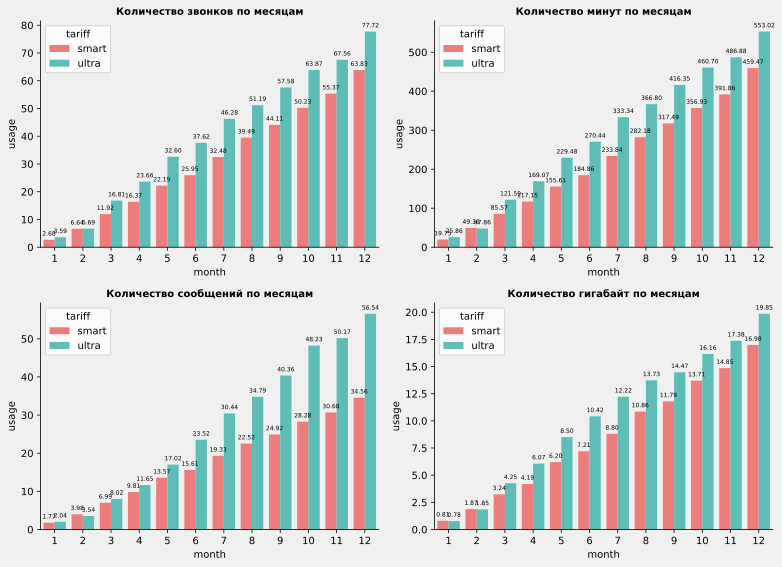

In [30]:
# Словарь для названий графиков
plot_dict = {
    1: 'Количество звонков',
    2: 'Количество минут',
    3: 'Количество сообщений',
    4: 'Количество гигабайт'
}

# Список данных для каждого графика
plot_list = [
    [calls_df, 'user_id', 'call_month', 'id', 'count'],
    [calls_df, 'user_id', 'call_month', 'duration', 'sum'],
    [messages_df, 'user_id', 'message_month', 'id', 'count'],
    [internet_df, 'user_id', 'session_month', 'gb_used', 'sum']
]

# Вычисление количества графиков и размеров сетки для их размещения
plot_num = len(plot_list)
col_num = 2
row_num = plot_num // col_num + (1 if plot_num % col_num > 0 else 0)

# Set the figure size based on the number of rows
plt.figure(figsize=(11, 4 * row_num))

for i, col in enumerate(plot_list, 1):
    plt.subplot(row_num, col_num, i)

    ax = sns.barplot(data=plot_data(users_data, *col), y='usage', x='month', hue='tariff', palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])

    # Настройка фона
    ax.set_facecolor('#F0F0F0')
    plt.gcf().set_facecolor('#F0F0F0')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=6)

    # Удаление верхней и правой границы графика
    sns.despine()

    plt.title(f'{plot_dict[i]} по месяцам', fontweight='bold', fontsize=10)

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()  # Display the plots




In [31]:
# Добавление столбца 'source' для идентификации источника данных
calls_data['source'] = 'calls'
messages_data['source'] = 'messages'
internet_data['source'] = 'internet'

# Объединение данных из разных источников и выбор нужных столбцов
total_profit = pd.concat([calls_data, messages_data, internet_data]).reset_index(drop=True).loc[:, ['user_id', 'tariff', 'source'] + list(range(1, 13))]

In [32]:
total_profit.head(3)

,user_id,tariff,source,1,2,3,4,5,6,7,8,9,10,11,12
0,1000,ultra,calls,0.0,0.0,0.0,0.0,1950.0,1950.0,1950.0,1950.0,1950.0,1950.0,1950.0,1950.0
1,1001,smart,calls,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,550.0,550.0
2,1002,smart,calls,0.0,0.0,0.0,0.0,0.0,550.0,550.0,550.0,550.0,550.0,550.0,550.0


In [33]:
# Преобразование данных из широкого формата в длинный
df_grouped = total_profit.melt(id_vars=['tariff'], value_vars=list(range(1, 13)), var_name='month', value_name='profit')

# Фильтрация данных для тарифа 'smart' и группировка по месяцам
df_grouped_smart = df_grouped[df_grouped['tariff'] == 'smart'].groupby('month')['profit'].sum().reset_index()

# Расчет накопительной прибыли
df_grouped_smart['cumulative_profit'] = df_grouped_smart['profit'].cumsum()

# Вычисление процентного изменения прибыли по сравнению с предыдущим месяцем
for i in range(1, len(df_grouped_smart['profit'])):
    df_grouped_smart.loc[i, 'percent_change'] = ((df_grouped_smart.loc[i, 'profit'] / df_grouped_smart.loc[i - 1, 'profit']) - 1) * 100

# Заполнение пустых значений нулями
df_grouped_smart.fillna(0, inplace=True)

# Вычисление среднего роста выручки за год от месяца к месяцу для тарифа 'smart'
average_growth = df_grouped_smart['percent_change'].mean()

print(f"Среднемесячный темп роста выручки тарифного плана Smart: {average_growth:.2f}%")


Среднемесячный темп роста выручки тарифного плана Smart: 32.21%


In [34]:
# Расчет годового темпа роста
first_month_revenue = df_grouped_smart.loc[df_grouped_smart['month'] == 1, 'profit'].values[0]
last_month_revenue = df_grouped_smart.loc[df_grouped_smart['month'] == 12, 'profit'].values[0]

annual_growth_rate = ((last_month_revenue / first_month_revenue) - 1) * 100

print("Годовой темп роста выручки тарифа Смарт:")
print(f"{annual_growth_rate:.2f}%")

Годовой темп роста выручки тарифа Смарт:
2071.31%


In [35]:
# Преобразование данных из широкого формата в длинный
df_grouped = total_profit.melt(id_vars=['tariff'], value_vars=list(range(1, 13)), var_name='month', value_name='profit')

# Фильтрация данных для тарифа 'ultra' и группировка по месяцам
df_grouped_ultra = df_grouped[df_grouped['tariff'] == 'ultra'].groupby('month')['profit'].sum().reset_index()

# Расчет накопительной прибыли
df_grouped_ultra['cumulative_profit'] = df_grouped_ultra['profit'].cumsum()

# Вычисление процентного изменения прибыли по сравнению с предыдущим месяцем
for i in range(1, len(df_grouped_ultra['profit'])):
    df_grouped_ultra.loc[i, 'percent_change'] = ((df_grouped_ultra.loc[i, 'profit'] / df_grouped_ultra.loc[i - 1, 'profit']) - 1) * 100

# Заполнение пустых значений нулями
df_grouped_ultra.fillna(0, inplace=True)

# Вычисление среднего роста выручки за год от месяца к месяцу для тарифа 'smart'
average_growth = df_grouped_ultra['percent_change'].mean()

print(f"Среднемесячный темп роста выручки тарифного плана Ultra: {average_growth:.2f}%")

Среднемесячный темп роста выручки тарифного плана Ultra: 31.95%


In [36]:
# Расчет годового темпа роста
first_month_revenue = df_grouped_ultra.loc[df_grouped_ultra['month'] == 1, 'profit'].values[0]
last_month_revenue = df_grouped_ultra.loc[df_grouped_ultra['month'] == 12, 'profit'].values[0]

annual_growth_rate = ((last_month_revenue / first_month_revenue) - 1) * 100

print("Годовой темп роста выручки тарифа Ультра:")
print(f"{annual_growth_rate:.2f}%")

Годовой темп роста выручки тарифа Ультра:
1605.13%


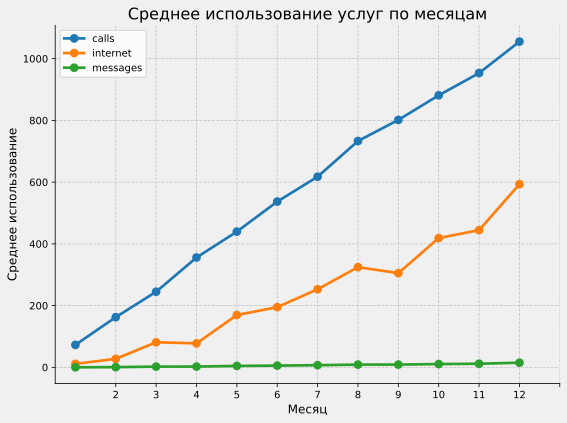

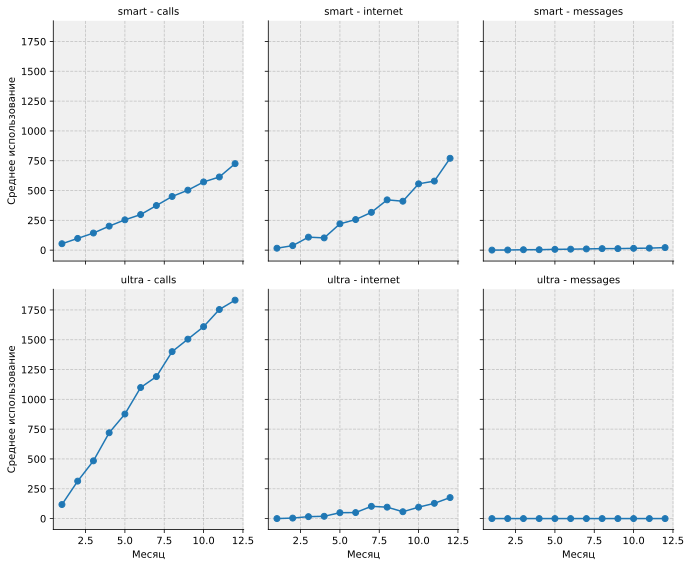

In [37]:

# 1. Подготовка данных
def prepare_data(df):
    # Преобразование данных в длинный формат
    df_long = df.melt(id_vars=['user_id', 'tariff', 'source'], 
                      var_name='month', value_name='usage')
    df_long['month'] = pd.to_numeric(df_long['month'])
    return df_long

# 2. Анализ сезонности
def analyze_seasonality(df_long):
    # Группировка по месяцам и источнику (услуге)
    monthly_usage = df_long.groupby(['month', 'source'])['usage'].mean().reset_index()
    
    # Создание графика
    plt.figure(figsize=(8, 6))
    for source in monthly_usage['source'].unique():
        data = monthly_usage[monthly_usage['source'] == source]
        ax = sns.pointplot(data=data, x='month', y='usage', label=source)

    # Настройка фона
    ax.set_facecolor('#F0F0F0')
    plt.gcf().set_facecolor('#F0F0F0')
    
    plt.title('Среднее использование услуг по месяцам', fontsize=16)
    plt.xlabel('Месяц', fontsize=12)
    plt.ylabel('Среднее использование', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(range(1, 13))

    # Удаление верхней и правой границы
    sns.despine()

    plt.tight_layout()
    plt.show()

# 3. Анализ по тарифам
def analyze_by_tariff(df_long):
    # Группировка по месяцам, источнику и тарифу
    tariff_usage = df_long.groupby(['month', 'source', 'tariff'])['usage'].mean().reset_index()
    
    # Создание графика
    g = sns.FacetGrid(tariff_usage, col='source', row='tariff', height=4, aspect=0.8)


    # Настройка фона для каждого подграфика
    for ax in g.axes.flat:
        ax.set_facecolor('#F0F0F0')
        ax.grid(linestyle='--', alpha=0.7)

    g.map(plt.plot, 'month', 'usage', marker='o')
    g.set_axis_labels('Месяц', 'Среднее использование')
    g.set_titles('{row_name} - {col_name}')
    g.add_legend()

    # Удаление верхней и правой границы
    sns.despine()

    plt.tight_layout()
    plt.show()

# Выполнение анализа
df_long = prepare_data(total_profit)
analyze_seasonality(df_long)
analyze_by_tariff(df_long)

In [38]:
# Группировка данных по тарифу и пользователю, суммирование прибыли по месяцам
total_grouped = total_profit.groupby(['tariff', 'user_id'], as_index=False)[list(range(1, 13))].sum()

# Расчет общей суммы прибыли за все месяцы и тарифы
total_revenue = total_grouped.loc[:, 1:12].sum().sum()

# Форматирование и вывод результата
print(f"Общая выручка за год: {total_revenue:,.2f} руб.")

Общая выручка за год: 4,916,951.00 руб.


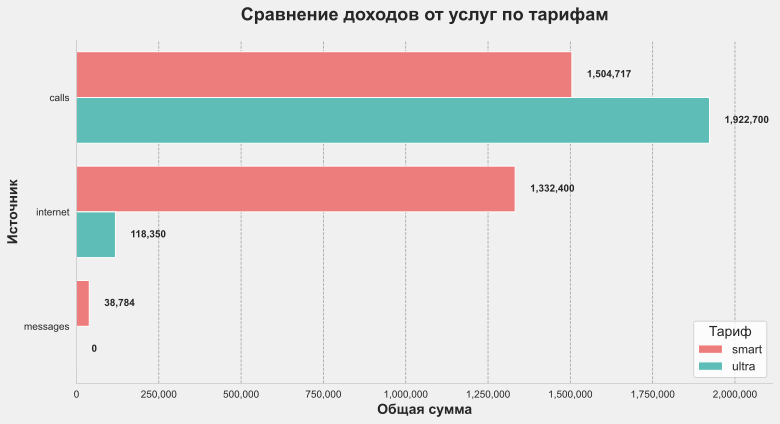

Сводная таблица по использованию услуг:
tariff   source     total
 smart    calls 1504717.0
 smart internet 1332400.0
 smart messages   38784.0
 ultra    calls 1922700.0
 ultra internet  118350.0
 ultra messages       0.0


In [39]:

def prepare_data(df):
    grouped = df.groupby(['tariff', 'source'], as_index=False)[list(range(1, 13))].sum()
    total_sum = grouped.groupby(['tariff', 'source'])[list(range(1, 13))].sum().sum(axis=1).reset_index(name='total')
    return total_sum

def plot_service_comparison(data):
    plt.figure(figsize=(11, 6))
    sns.set_style("whitegrid")
    
    # Создаем основной график
    ax = sns.barplot(data=data, x='total', y='source', hue='tariff', 
                     palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    
    # Настройка фона
    ax.set_facecolor('#F0F0F0')
    plt.gcf().set_facecolor('#F0F0F0')
    
    # Стилизация графика
    ax.set_xlabel('Общая сумма', fontsize=14, fontweight='bold')
    ax.set_ylabel('Источник', fontsize=14, fontweight='bold')
    ax.set_title('Сравнение доходов от услуг по тарифам', fontsize=18, fontweight='bold', pad=20)
    
    # Удаление верхней и правой границы
    sns.despine()
    
    # Добавление подписей к столбцам
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=15, fontsize=10, fontweight='bold')
    
    # Настройка легенды
    ax.legend(title='Тариф', title_fontsize='14', fontsize='12', loc='lower right', frameon=True)
    
    # Установка пределов оси X и форматирование чисел
    plt.xlim(0, data['total'].max() * 1.1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
    # Добавление вертикальных линий для улучшения читаемости
    ax.grid(axis='x', linestyle='--', alpha=0.7, color='gray')
    
    
    plt.tight_layout()
    return ax

# Подготовка данных
total_service_sum = prepare_data(total_profit)

# Построение и отображение графика
ax = plot_service_comparison(total_service_sum)
plt.show()

# Вывод данных в отформатированном виде
print("Сводная таблица по использованию услуг:")
print(total_service_sum.to_string(index=False))

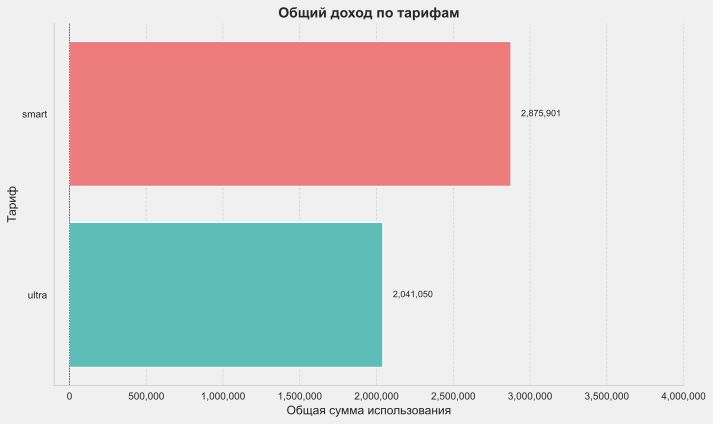

Результаты группировки по тарифам:
tariff  total_amount
 smart     2875901.0
 ultra     2041050.0


In [40]:

# Группировка данных по тарифу и источнику, суммирование по месяцам
source_grouped = total_profit.groupby(['tariff', 'source'], as_index=False)[list(range(1, 13))].sum()

# Группировка данных по тарифу и расчет общей суммы
def calculate_total_amount(df):
    return df.groupby('tariff')[list(range(1, 13))].sum().sum(axis=1).reset_index(name='total_amount')

total_source_grouped = calculate_total_amount(source_grouped)

# Создание функции для построения графика
def plot_tariff_comparison(data):
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=data, x='total_amount', y='tariff', palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])

    # Настройка фона
    ax.set_facecolor('#F0F0F0')
    plt.gcf().set_facecolor('#F0F0F0')
    
    # Стилизация графика
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Общая сумма использования', fontsize=12)
    ax.set_ylabel('Тариф', fontsize=12)
    ax.set_title('Общий доход по тарифам', fontsize=14, fontweight='bold')
    
    # Добавление подписей к столбцам
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=10, fontsize=9)
    
    # Установка пределов оси X и форматирование чисел
    plt.xlim(-100000, 4000000)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # Улучшение внешнего вида
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    return ax

# Построение и отображение графика
ax = plot_tariff_comparison(total_source_grouped)

sns.despine()

plt.show()


# Вывод численных результатов
print("Результаты группировки по тарифам:")
print(total_source_grouped.to_string(index=False))



In [41]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Создание сводной таблицы
test_df = total_service_sum.pivot_table(index='source', columns='tariff', values='total').reset_index().rename_axis(None, axis=1)

# Преобразование названий столбцов к формату с заглавной буквы
test_df.columns = test_df.columns.str.title()

# Добавление столбца с разницей между тарифами Smart и Ultra
test_df['Разница (Smart - Ultra)'] = test_df.apply(lambda x: x['Smart'] - x['Ultra'], axis=1)

# Переименование столбца 'Source' на 'Источник'
test_df = test_df.rename(columns={'Source': 'Источник'})

# Перевод значений в столбце 'Источник' на русский язык
test_df['Источник'] = test_df['Источник'].map({'calls': 'Звонки', 'internet': 'Интернет', 'messages': 'Сообщения', 'Итого': 'Итого'})

# Добавление строки с итоговыми значениями
test_df.loc[3, 'Источник'] = 'Итого'
test_df.loc[3, ['Smart', 'Ultra']] = test_df[['Smart', 'Ultra']].apply(lambda x: x.sum())
test_df.loc[3, 'Разница (Smart - Ultra)'] = test_df.loc[3, ['Smart', 'Ultra']].sum()

# Вывод результирующей таблицы
test_df

,Источник,Smart,Ultra,Разница (Smart - Ultra)
0,Звонки,1504717.00,1922700.00,-417983.00
1,Интернет,1332400.00,118350.00,1214050.00
2,Сообщения,38784.00,0.00,38784.00
3,Итого,2875901.00,2041050.00,4916951.00


In [42]:
df = total_service_sum.merge(total_service_sum.groupby('tariff')['total'].sum().reset_index(), on='tariff', how='left')
df['percent_of_total'] = df['total_x'].div(df['total_y']).mul(100)
df.pivot(index='source', columns='tariff', values='percent_of_total').reset_index().rename_axis(None, axis=1)

,source,smart,ultra
0,calls,52.32,94.20
1,internet,46.33,5.80
2,messages,1.35,0.00




1. Сравнение доходов по источникам:

| Источник | Smart    | Ultra    | Разница (Smart - Ultra) |
|----------|----------|----------|-----------------------|
| Звонки   | 1,504,717| 1,922,700| -417,983              |
| Интернет | 1,332,400| 118,350  | 1,214,050             |
| Сообщения| 38,784   | 0        | 38,784                |
| Итого    | 2,875,901| 2,041,050| 834,851               |

2. Процентное распределение доходов:

| Источник | Smart  | Ultra |
|----------|--------|-------|
| Звонки   | 52.32% | 94.20%|
| Интернет | 46.33% | 5.80% |
| Сообщения| 1.35%  | 0%    |
| Итого    | 100%   | 100%  |

3. Сравнение эффективности тарифов:

| Метрика                    | Smart    | Ultra    | Лидер |
|----------------------------|----------|----------|-------|
| Общий доход                | 2,875,901| 2,041,050| Smart |
| Доход от звонков           | 1,504,717| 1,922,700| Ultra |
| Доход от интернета         | 1,332,400| 118,350  | Smart |
| Доход от сообщений         | 38,784   | 0        | Smart |
| Разнообразие услуг (из 3)  | 3        | 2        | Smart |

Выводы:
1. Тариф Smart более сбалансирован и приносит больший общий доход.
2. Ultra доминирует в сегменте звонков, но отстает по другим услугам.
3. Интернет-услуги - ключевое преимущество тарифа Smart.
4. Сообщения не используются в тарифе Ultra, что может быть областью для улучшения.



## <a id='hypotheses'></a> 5️⃣ Проверка гипотез


[**Главное меню**](#menu)

#### <a id='hyp_1'></a> 1. Средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются


In [43]:
# Фильтрация данных для тарифа 'smart' и группировка по user_id
smart_df = total_profit[total_profit['tariff'] == 'smart'].groupby('user_id')[list(range(1, 13))].sum().reset_index()

# Добавление столбца 'total' с суммой по всем месяцам для каждого пользователя
smart_df['total'] = smart_df[list(range(1, 13))].sum(axis=1)

In [44]:
# Фильтрация данных для тарифа 'ultra' и группировка по user_id
ultra_df = total_profit[total_profit['tariff'] == 'ultra'].groupby('user_id')[list(range(1, 13))].sum().reset_index()

# Добавление столбца 'total' с суммой по всем месяцам для каждого пользователя
ultra_df['total'] = ultra_df[list(range(1, 13))].sum(axis=1)

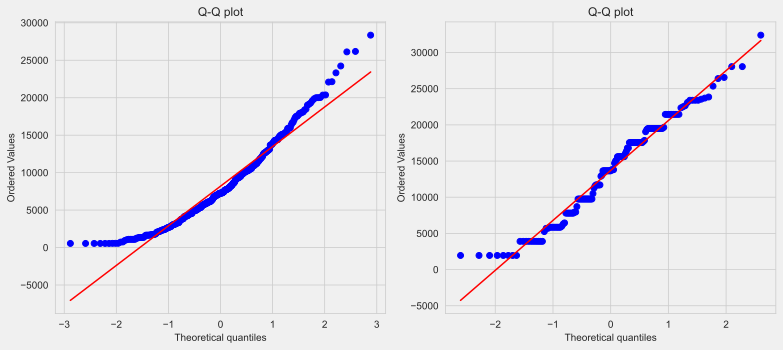

In [45]:
# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# QQ-plot
stats.probplot(smart_df['total'], dist="norm", plot=ax1)
ax1.set_title("Q-Q plot")
ax1.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')

# QQ-plot
stats.probplot(ultra_df['total'], dist="norm", plot=ax2)
ax2.set_title("Q-Q plot")
ax2.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')

plt.tight_layout()
plt.show()

In [46]:
# Функция для проверки нормальности распределения
def test_normality(data, name):
    statistic, p_value = shapiro(data)
    return pd.DataFrame({
        'Датасет': [name],
        'Статистика': [statistic],
        'p-значение': [p_value],
        'Вывод': ['Распределение нормальное' if p_value > 0.05 else 'Распределение не нормальное']
    })

# Применение теста нормальности к обоим датасетам
results = pd.concat([
    test_normality(smart_df['total'], 'Smart'),
    test_normality(ultra_df['total'], 'Ultra')
])

# Настройка формата вывода чисел
pd.set_option('display.float_format', '{:.6f}'.format)

# Вывод результатов
print(results.to_string(index=False))

# Вывод интерпретации результатов
print("\nИнтерпретация:")
print("p-значение > 0.05: не отвергаем гипотезу о нормальности")
print("p-значение <= 0.05: отвергаем гипотезу о нормальности")

Датасет  Статистика  p-значение                       Вывод
  Smart    0.942828    0.000000 Распределение не нормальное
  Ultra    0.971032    0.003065 Распределение не нормальное

Интерпретация:
p-значение > 0.05: не отвергаем гипотезу о нормальности
p-значение <= 0.05: отвергаем гипотезу о нормальности


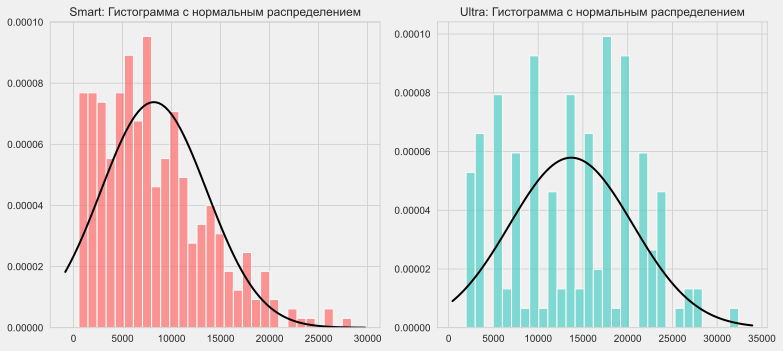

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# График для smart_df['total']
ax1.hist(smart_df['total'], bins=30, density=True, alpha=0.7, color='#FF6B6B')
# Настройка фона
ax1.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')
mu1, std1 = norm.fit(smart_df['total'])
xmin1, xmax1 = ax1.get_xlim()
x1 = np.linspace(xmin1, xmax1, 100)
p1 = norm.pdf(x1, mu1, std1)
ax1.plot(x1, p1, 'k', linewidth=2)
ax1.set_title("Smart: Гистограмма с нормальным распределением")

# График для ultra_df['total']
ax2.hist(ultra_df['total'], bins=30, density=True, alpha=0.7, color='#4ECDC4')
# Настройка фона
ax2.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')
mu2, std2 = norm.fit(ultra_df['total'])
xmin2, xmax2 = ax2.get_xlim()
x2 = np.linspace(xmin2, xmax2, 100)
p2 = norm.pdf(x2, mu2, std2)
ax2.plot(x2, p2, 'k', linewidth=2)
ax2.set_title("Ultra: Гистограмма с нормальным распределением")

plt.tight_layout()
plt.show()

$$
\begin{cases}
H_0: \text{Средняя выручка пользователей тарифов «Ультра» и «Смарт» одинакова.} \\
H_1: \text{Средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются.}
\end{cases}
$$

In [48]:
from scipy.stats import mannwhitneyu

# Предполагаем, что у вас есть две группы данных: group1 и group2
statistic, p_value = mannwhitneyu(ultra_df['total'], smart_df['total'], alternative='two-sided')

# Оформляем вывод
results = pd.DataFrame({
    'Тест': ['Манна-Уитни'],
    'Статистика': [statistic],
    'p-значение': [p_value]
})

# Устанавливаем форматирование для чисел
pd.set_option('display.float_format', '{:.6f}'.format)

# Добавляем интерпретацию результата
alpha = 0.05  # уровень значимости
results['Вывод'] = np.where(results['p-значение'] > alpha, 
                            'Не получилось отвергнуть нулевую гипотезу',
                            'Отвергаем нулевую гипотезу')

# Выводим результаты
print(results.to_string(index=False))

print(f"\nУровень значимости: {alpha}")
print("Интерпретация:")
print("Если p-значение > уровня значимости, мы не отвергаем нулевую гипотезу об отсутствии различий между группами.")
print("Если p-значение <= уровня значимости, мы отвергаем нулевую гипотезу и заключаем, что есть значимые различия между группами.")

       Тест   Статистика  p-значение                      Вывод
Манна-Уитни 38175.500000    0.000000 Отвергаем нулевую гипотезу

Уровень значимости: 0.05
Интерпретация:
Если p-значение > уровня значимости, мы не отвергаем нулевую гипотезу об отсутствии различий между группами.
Если p-значение <= уровня значимости, мы отвергаем нулевую гипотезу и заключаем, что есть значимые различия между группами.


#### <a id='hyp_2'></a> 2. Средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов

In [49]:
# Устанавливаем форматирование для чисел
pd.set_option('display.float_format', '{:.2f}'.format)

total_df = total_profit.groupby('user_id')[list(range(1, 13))].sum().reset_index()
total_df['total'] = total_df[list(range(1, 13))].sum(axis=1)
total_df

,user_id,1,2,3,4,5,6,7,8,9,10,11,12,total
0,1000,0.00,0.00,0.00,0.00,1950.00,1950.00,1950.00,1950.00,1950.00,1950.00,1950.00,1950.00,15600.00
1,1001,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1150.00,550.00,1700.00
2,1002,0.00,0.00,0.00,0.00,0.00,550.00,1150.00,1550.00,950.00,550.00,1350.00,1150.00,7250.00
3,1003,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1950.00,1950.00,1950.00,1950.00,1950.00,9750.00
4,1004,0.00,0.00,0.00,0.00,1950.00,1950.00,1950.00,1950.00,1950.00,1950.00,1950.00,1950.00,15600.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1495,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1950.00,2400.00,1950.00,3300.00,1950.00,11550.00
496,1496,550.00,3432.00,2721.00,1813.00,2350.00,1715.00,2596.00,2231.00,2950.00,3150.00,3036.00,1807.00,28351.00
497,1497,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,550.00,550.00,1685.00,2785.00
498,1498,0.00,0.00,0.00,0.00,0.00,0.00,550.00,2386.00,1950.00,1750.00,0.00,0.00,6636.00


In [50]:
# Объединение данных о пользователях с общей таблицей по user_id
cities_df = total_df.merge(user_df[['user_id', 'city']], on='user_id', how='right')

# Выделение данных для Москвы
moscow = cities_df.loc[cities_df['city'] == 'Москва', 'total']

# Выделение данных для остальных городов
other_cities = cities_df.loc[cities_df['city'] != 'Москва', 'total']

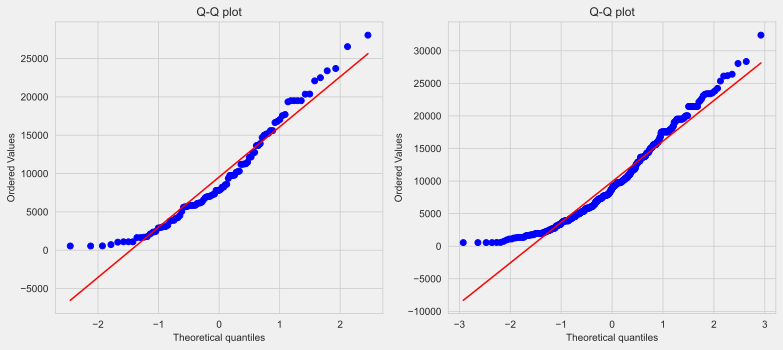

In [51]:
# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# QQ-plot
stats.probplot(moscow, dist="norm", plot=ax1)
ax1.set_title("Q-Q plot")
ax1.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')

# QQ-plot
stats.probplot(other_cities, dist="norm", plot=ax2)
ax2.set_title("Q-Q plot")
ax2.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')

plt.tight_layout()
plt.show()

In [52]:
def test_normality(data, name):
    statistic, p_value = shapiro(data)
    return pd.DataFrame({
        'Датасет': [name],
        'Статистика': [statistic],
        'p-значение': [p_value],
        'Вывод': ['Распределение нормальное' if p_value > 0.05 else 'Распределение не нормальное']
    })

results = pd.concat([
    test_normality(moscow, 'Москва'),
    test_normality(other_cities, 'Другие города')
])

pd.set_option('display.float_format', '{:.6f}'.format)
print(results.to_string(index=False))

print("\nИнтерпретация:")
print("p-значение > 0.05: не отвергаем гипотезу о нормальности")
print("p-значение <= 0.05: отвергаем гипотезу о нормальности")

      Датасет  Статистика  p-значение                       Вывод
       Москва    0.939146    0.000185 Распределение не нормальное
Другие города    0.949712    0.000000 Распределение не нормальное

Интерпретация:
p-значение > 0.05: не отвергаем гипотезу о нормальности
p-значение <= 0.05: отвергаем гипотезу о нормальности


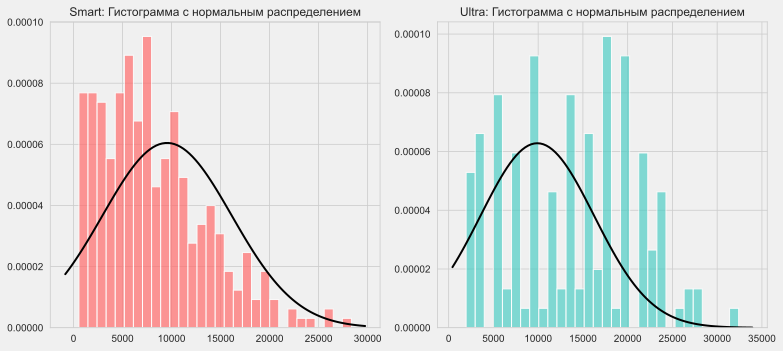

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# График для smart_df['total']
ax1.hist(smart_df['total'], bins=30, density=True, alpha=0.7, color='#FF6B6B')
# Настройка фона
ax1.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')
mu1, std1 = norm.fit(moscow)
xmin1, xmax1 = ax1.get_xlim()
x1 = np.linspace(xmin1, xmax1, 100)
p1 = norm.pdf(x1, mu1, std1)
ax1.plot(x1, p1, 'k', linewidth=2)
ax1.set_title("Smart: Гистограмма с нормальным распределением")

# График для ultra_df['total']
ax2.hist(ultra_df['total'], bins=30, density=True, alpha=0.7, color='#4ECDC4')
# Настройка фона
ax2.set_facecolor('#F0F0F0')
plt.gcf().set_facecolor('#F0F0F0')
mu2, std2 = norm.fit(other_cities)
xmin2, xmax2 = ax2.get_xlim()
x2 = np.linspace(xmin2, xmax2, 100)
p2 = norm.pdf(x2, mu2, std2)
ax2.plot(x2, p2, 'k', linewidth=2)
ax2.set_title("Ultra: Гистограмма с нормальным распределением")

plt.tight_layout()
plt.show()

$$
\begin{cases}
H_0: \text{Cредняя выручка пользователей из Москвы и регионов одинакова.} \\
H_1: \text{Cредняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов.}
\end{cases}
$$

In [54]:
# Предполагаем, что у вас есть две группы данных: group1 и group2
statistic, p_value = mannwhitneyu(moscow, other_cities, alternative='two-sided')

# Оформляем вывод
results = pd.DataFrame({
    'Тест': ['Манна-Уитни'],
    'Статистика': [statistic],
    'p-значение': [p_value]
})

# Устанавливаем форматирование для чисел
pd.set_option('display.float_format', '{:.6f}'.format)

# Добавляем интерпретацию результата
alpha = 0.05  # уровень значимости
results['Вывод'] = np.where(results['p-значение'] > alpha, 
                            'Не получилось отвергнуть нулевую гипотезу',
                            'Отвергаем нулевую гипотезу')

# Выводим результаты
print(results.to_string(index=False))

print(f"\nУровень значимости: {alpha}")
print("Интерпретация:")
print("Если p-значение > уровня значимости, мы не отвергаем нулевую гипотезу об отсутствии различий между группами.")
print("Если p-значение <= уровня значимости, мы отвергаем нулевую гипотезу и заключаем, что есть значимые различия между группами.")

       Тест   Статистика  p-значение                                     Вывод
Манна-Уитни 18999.000000    0.509081 Не получилось отвергнуть нулевую гипотезу

Уровень значимости: 0.05
Интерпретация:
Если p-значение > уровня значимости, мы не отвергаем нулевую гипотезу об отсутствии различий между группами.
Если p-значение <= уровня значимости, мы отвергаем нулевую гипотезу и заключаем, что есть значимые различия между группами.
